 # Classifiers KNN - SVM - MLP & CNN
 The goal of this extra is to do thae same as the previous but with the MNIST dataset and a Convolutional Neural Network (CNN) classifier.

### Importing Libraries

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
# for the classifiers
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score, log_loss
from sklearn.neighbors import KNeighborsClassifier as KNN # K-Nearest Neighbors
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier as MLP # Multi-layer Perceptron

## MNIST dataset
Looking at the MNIST dataset by printing first 10 images with their labels, the number of samples for each label and its shape.

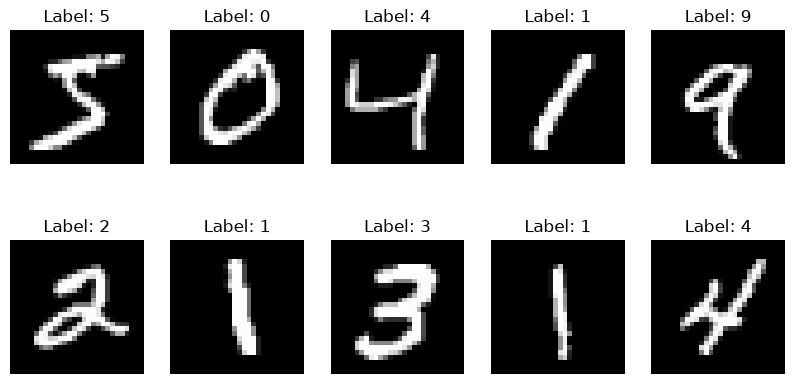

0:6903   1:7877   2:6990   3:7141   4:6824   5:6313   6:6876   7:7293   8:6825   9:6958  
X shape: (70000, 784) | y shape: (70000,)


In [3]:
mnist = fetch_openml("mnist_784", as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.axis('off')
    plt.imshow(X[i].reshape(28, 28), cmap='grey')
    plt.title(f"Label: {y[i]}")
plt.show()

print(*(f"{i}:{np.bincount(y)[i]}  " for i in range(10)))
print(f"X shape: {X.shape} | y shape: {y.shape}")

#### KNN - SVM - MLP
The next code cells will be used to train and test the KNN, SVM and MLP classifiers with the MNIST dataset. It will not use GridSearch, since the goal is just to show slow performance of these classifiers with a large dataset. The data will be scaled.

In [5]:
pipe = make_pipeline(StandardScaler(), KNN(n_neighbors=3, weights="distance"))

pipe.fit(X_tr, y_tr)
print(pipe.score(X_te, y_te))

0.9469285714285715


In [6]:
pipe = make_pipeline(StandardScaler(), SVC(C=10, gamma=0.001, kernel="rbf"))

pipe.fit(X_tr, y_tr)
print(pipe.score(X_te, y_te))

0.9711428571428572


In [7]:
pipe = make_pipeline(StandardScaler(), MLP(hidden_layer_sizes=(128, 64), alpha=0.001, max_iter=1000, random_state=42))

pipe.fit(X_tr, y_tr)
print(pipe.score(X_te, y_te))

0.9770714285714286


In [ ]:
data_scaling = list()
data_models = list()
data_classification_report = list()
models = dict()

classifiers = {"KNN": (KNN(), {"clf__n_neighbors": [3, 5], "clf__weights": ["uniform", "distance"]}), 
               "SVM": (SVC(), {"clf__C": [1, 10], "clf__gamma": ["scale", 0.001], "clf__kernel": ["rbf"]}), 
               "MLP": (MLP(max_iter=1000, random_state = 42), {"clf__hidden_layer_sizes": [(128,), (128, 64)], "clf__alpha": [0.001, 0.01]})}

for name, (clf, params) in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        grid = GridSearchCV(pipe, params, cv=3, n_jobs=-1)
        grid.fit(X_tr, y_tr)

        # Storing each winner model
        models[name] = grid.best_estimator_

        # Transfering best_params_ value into readable content to store in the pandas DataFrame
        best_params = grid.best_params_
        params_str = ", ".join(f"{key.replace('clf__', '')} = {value}" for key, value in best_params.items() if key != "scaler")
        
        # Calculating time prediction to store it
        t0 = time.perf_counter()
        y_pred = grid.predict(X_te)
        pred_time = time.perf_counter() - t0

        # Storing accuracy to avoid re-scoring since it's used more than once
        accuracy = accuracy_score(y_te, y_pred)

        # Table for comparison between models
        data_models.append({"Classifier": name,
                            "Best Parameters": params_str,
                            "CV mean": grid.best_score_, 
                            "CV std": grid.cv_results_["std_test_score"][grid.best_index_],
                            "Test accuracy": accuracy,
                            "F1": f1_score(y_te, y_pred, average="macro"), 
                            "Training time (ms)": grid.refit_time_/len(y_pred) * 1000, # s -> ms
                            "Prediction time (ms)": pred_time * 1000}) # s -> ms

        #print("{}:\n\nBest Params: {}\nBest Score CV: {:.3f}/1.000\nAccuracy: {:.3f}/1.000\n".format(name, grid.best_params_, grid.best_score_, accuracy))
        
        data_classification_report.append(pd.DataFrame(classification_report(y_te, y_pred, zero_division=0, output_dict=True)).round(4).T)

        ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

### Training/Cross-validation Loss & Accuracy Curve for MLP Classifier
This code will generate a plot with the training and cross-validation loss and accuracy curves for the MLP classifier, in order to visualize if the epoch number is correct.

In [ ]:
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

scaler = StandardScaler().fit(X_fit)
X_fit_s, X_val_s = scaler.transform(X_fit), scaler.transform(X_val)

mlp = MLP(hidden_layer_sizes=(128, 64), alpha=0.001, random_state=42)
train_acc, val_acc = list(), list()
train_loss, val_loss = list(), list()

for epoch in range(200):
    mlp.partial_fit(X_fit_s, y_fit, classes=np.unique(y_tr))
    
    train_acc.append(mlp.score(X_fit_s, y_fit))
    val_acc.append(mlp.score(X_val_s, y_val))

    train_loss.append(log_loss(y_fit, mlp.predict_proba(X_fit_s)))
    val_loss.append(log_loss(y_val, mlp.predict_proba(X_val_s)))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("MLP Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("MLP Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Classification Report for KNN, SVM and MLP Classifiers

- KNN Classifier

In [ ]:
data_classification_report[0]

- SVM Classifier

In [ ]:
data_classification_report[1]

- MLP Classifier

In [ ]:
data_classification_report[2]

### Results Tables

In [ ]:
pd_data_scaling = pd.DataFrame(data_scaling).set_index("Classifier").round(4)
pd_data_scaling

In [ ]:
pd_data_models = pd.DataFrame(data_models).set_index("Classifier").round(4)
pd_data_models

### Misclassified Images for KNN, SVM and MLP Classifiers

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_te)
    wrong = np.where(y_pred != y_te)[0]
    n_cols = min(10, len(wrong))
    n_rows = int(np.ceil(len(wrong) / n_cols))

    plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
    plt.suptitle(f"Misclassified Digits - {name}")

    for k, i in enumerate(wrong):
        plt.subplot(n_rows, n_cols, k + 1)
        plt.imshow(X_te[i].reshape(8, 8), cmap="gray")
        plt.title(f"Label: {y_te[i]}")
        plt.xlabel(f"Prediction: {y_pred[i]}")
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()


#### CNN
> Not even going to bother testing without scaling, since CNN is a neural network and it will defenitely benefit from scaling.

In [ ]:

X_tr_t = torch.tensor(X_tr / 255.0, dtype=torch.float32).reshape(-1, 1, 28, 28)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)

full_train = TensorDataset(X_tr_t, y_tr_t)
train_ds, val_ds = random_split(full_train, [0.9, 0.1], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)

In [27]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (32,14,14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (64,7,7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # → 64*7*7 = 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),           # 10 digits
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [28]:
torch.manual_seed(42)   # same role as random_state=42 for the MLP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [29]:
def train_one_epoch(model, loader):
    model.train()                               # turns Dropout on
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)       # batch → GPU

        optimizer.zero_grad()                   # 1. clear the previous gradients
        out = model(X)                          # 2. forward pass: predictions
        loss = loss_fn(out, y)                  # 3. how wrong they are
        loss.backward()                         # 4. backpropagation: compute the gradients
        optimizer.step()                        # 5. update the weights

        total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)

@torch.no_grad()                                # no gradients needed: faster, less memory
def predict(model, loader):
    model.eval()                                # turns Dropout off
    preds = []
    for X, _ in loader:
        out = model(X.to(device))
        preds.append(out.argmax(dim=1).cpu())   # highest score = predicted class
    return torch.cat(preds).numpy()

In [ ]:
y_val = y_tr_t[val_ds.indices].numpy()   # true labels of the validation split (val_loader isn't shuffled, so order matches)

t0 = time.perf_counter()
for epoch in range(10):
    loss = train_one_epoch(model, train_loader)
    val_acc = accuracy_score(y_val, predict(model, val_loader))
    print(f"epoch {epoch+1}: loss {loss:.4f} | val acc {val_acc:.4f}")
if device.type == "cuda":
    torch.cuda.synchronize()    # wait for the GPU to finish before stopping the clock
train_time = time.perf_counter() - t0


epoch 1: loss 0.0298 | val acc 0.9902
epoch 2: loss 0.0283 | val acc 0.9896
epoch 3: loss 0.0226 | val acc 0.9916
epoch 4: loss 0.0211 | val acc 0.9916
epoch 5: loss 0.0165 | val acc 0.9911
epoch 6: loss 0.0158 | val acc 0.9914
epoch 7: loss 0.0150 | val acc 0.9918
epoch 8: loss 0.0130 | val acc 0.9904
epoch 9: loss 0.0112 | val acc 0.9912
epoch 10: loss 0.0107 | val acc 0.9916
epoch 11: loss 0.0102 | val acc 0.9907
epoch 12: loss 0.0083 | val acc 0.9934
epoch 13: loss 0.0101 | val acc 0.9920
epoch 14: loss 0.0079 | val acc 0.9912
epoch 15: loss 0.0081 | val acc 0.9921
epoch 16: loss 0.0072 | val acc 0.9912
epoch 17: loss 0.0065 | val acc 0.9929
epoch 18: loss 0.0064 | val acc 0.9916
epoch 19: loss 0.0059 | val acc 0.9923
epoch 20: loss 0.0063 | val acc 0.9912
